<a href="https://colab.research.google.com/github/nilotpal-makes-stuff/Python_TensorFlow-text_classification/blob/main/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python TensorFlow - Text Classification
Python TensorFlow for Machine Learning – Neural Network Text Classification Tutorial FreeCodeCamp.  
Youtube link - https://www.youtube.com/watch?v=VtRLrQ3Ev-U

## Libraries required
* numpy
* pandas
* matplotlib.pyplot
* tensorflow
* tensorflow_hub

**tensorflow_hub** is an open source python library which is used to publish, discover and use reuseable parts of machine learning models. Key features :
* Wraps **SavedModels** as Keras Layers to enable transfer learning with pre-trained models
* Provides access to repository of trained models
* Models can be loaded directly into TensorFlow 2 workflows - caching handled automatically in system's temporary directories.

In [ ]:
#Importing libraries
import numpy
import pandas
import matplotlib.pyplot as pyplot
import tensorflow
import tensorflow_hub as hub

import datetime
datetime.datetime.now().strftime("%H:%M:%S")

'08:16:55'

## Uploading datasets
We can manage google colab directories for the project using the folder icon(left). We can also upload datasets into google colab which can be used in the project.

Dataset source - https://drive.google.com/drive/folders/1YnxDqNIqM2Xr1Dlgv5pYsE6dYJ9MGxcM

## Reading data into DataFrame
Now we will read the csv file contents into a pandas DataFrame.

In [ ]:
wine_csvfile = "/content/wine-reviews.csv"

#Complete csv file read into dataframe
wine_df_complete = pandas.read_csv(wine_csvfile)

#Select columns only read into dataframe
wine_df_select = pandas.read_csv(wine_csvfile, usecols=['country','description','points','price','winery', 'variety'])


In [ ]:
#wine_df_complete.head()

In [ ]:
wine_df_select.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


# Dropping Missing values
Datasets often contain missing values - depicted as "NaN" - we need to appropriately handle these missing values depending on the project requirement.

We can remove rows containing "NaN" values using the **DataFrame.dropna()** method. We can also use parameter **"subset"** to specify list of columns in which we will look for the NaN values and drop the rows containing NaN values.

**DataFrame.dropna()** returns a copy of dataframe with rows dropped.

Let us consider the scenario where we are trying to figure out the relation between 'description' column and 'points' column. We drop NaN valued rows for these two columns only.

In [ ]:
#Before running dropna() nan values count
print(f"Before dropna() NaN values :\ncolumn 'description' = {wine_df_select['description'].isna().sum()}\ncolumn 'points' = {wine_df_select['points'].isna().sum()}")

#drop nan valued rows
wine_df_select_nonan = wine_df_select.dropna(subset=['description', 'points'])

#After running dropna() nan values count
print()
print(f"After dropna() NaN values :\ncolumn 'description' = {wine_df_select_nonan['description'].isna().sum()}\ncolumn 'points' = {wine_df_select_nonan['points'].isna().sum()}")

Before dropna() NaN values :
column 'description' = 0
column 'points' = 0

After dropna() NaN values :
column 'description' = 0
column 'points' = 0


## Distribution of points
Now lets check the distribution of points values using a histogram. We use **matplotlib.pyplot.hist()** method to plot a **histogram**. **matplotlib.pyplot.hist()** takes in the axes as parameter - axes can be just one axis (single list) or two separate axes (two lists).  
Parameters :
* data - list of values
* bins - If bins is an integer, it defines the number of equal-width bins in the range. If bins is a sequence, it defines the bin edges, including the left edge of the first bin and the right edge of the last bin
* color - color of plot
* density - boolean value - True to normalise area of distribution to 1 else no normalization
* rwidth - width of the histogram column drawn.



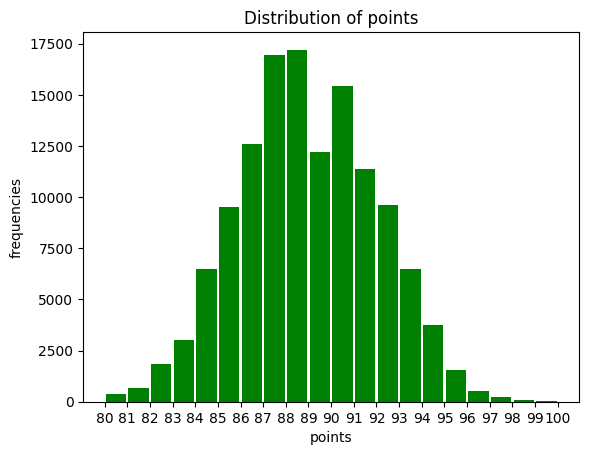

In [ ]:
#This gives us the x-axis values for edges of the bins
_, bins = numpy.histogram(wine_df_select_nonan['points'], bins=20)

#Plotting points distribution
pyplot.hist(wine_df_select_nonan['points'], bins=20, color='green', rwidth=0.9)
#Plot x-axis ticks for each bin
pyplot.xticks(bins)

#Title and Labels
pyplot.title("Distribution of points")
pyplot.xlabel('points')
pyplot.ylabel('frequencies')

#Display
pyplot.show()

Looking at the distribution we can see that the **points** in this dataset range from 80 to 100. Lets consider a requirement : Predict that a wine from the wine dataset falls into one of two groups - **"score below 90 points"** and **"score above 90 points"** based on their **'description'** column.

For this problem we need to construct a machine learning model which will look at "description" and determine with reasonable accuracy which category the row falls into.

# What is Machine Learning
**Machine Learning** is a subdomain of Computer Science which focuses on algorithms which help a computer learn from data without explicit programming.

**Artificial Intelligence** is an area of Computer Science which enables computers and machines to perform human like tasks and simulate human behaviour.
Machine Learning is a subset of AI, it solves problems by making predictions using the data available.

**Data Science** is a field attempting to find patterns and draw insights from data - sometimes uses machine learning models/techniques

All three of the above overlap often.

There are multiple types of Machine Learning :
* **Supervised Learning** - Uses labelled inputs to (input data has corresponding output labels) to train models and learn outputs and then make predictions on unlabelled data.
* **Unsupervised Learning** - uses unlabelled data to learn about patterns in data. The model tries to learn the inherent structure or pattern in data provided and categorise the data into groups based on the similarity of patterns in the data.
* **Reinforcement Learning** - Model learns in an interactive environment based on **rewards** for correct prediction or required behaviour and **penalites** for incorrect prediction or unwanted behaviour.

In this project we focus on Supervised Learning.

## Supervised Learning
A basic diagram of a Machine Learning Model looks like this :  
![Machine Learning model](images/01.ML Model.png)

A **series of inputs** are provided to the model and the model tries to predict an **output value** for the series of inputs (or the model might generate some sort of output which is not a value, depending on the model).

The model tries to learn patterns in the input and comes up with an output prediction. The list of inputs are collectively called the **"Feature Vector"**.

## Features
There are different types of **Features** or inputs :
* **Qualitative** - Categorical data (data is divided into finite number of groups or categories) which depict a quality about the data. Qualitative data is of two types :
    * **Nominal Data** - qualitative data which donot have any inherent ordering. Example : Countries, Gender, Ethnicity

    * **Oridinal Data** - qualitative data which have inherent ordering. Example : age groups, satisfaction level in customer survey.

Since computers are efficient in dealing with numbers, we often convert qualitative data into numbers representing the qualitative data.

We use a method called **"One Hot Encoding"** to convert **Nominal data** into numerical data. **One Hot Encoding** converts data into numerical data by creating a unique binary column for each unique category where 1 indicates its presence and 0 indicates its absence.  
Example : For categories [India, Japan, China, Russia], one hot encoding gives us {India:[1,0,0,0], Japan:[0,1,0,0], China:[0,0,1,0], Russia:[0,0,0,1]}.  
One Hot Encoding is mainly used in Machine Learning to eliminate **Artificial Ordinality** - algorithms interpret categorical labels as having a numerical ranking or hierarchy.

We can represent **"Ordinal Data"** categories in numerical format using the inherent order in the data.

* **Quantitative Data** - Numerical valued data which is of two types **discrete** or **continuous**.

These together are the type of features that we can feed into out Machine Learning Model.

## Types of Predictions
